# Assignment 2: k Nearest Neighbor
Kaitlin Luu

### Q1.

**1. What is the difference between regression and classification?** <br>
Regression predicts continuous numerical values such as rainfall. Classification predicts discrete categories such as presence of a disease, inm which case the labels would be positive or negative. 

**2. What is a confusion table/matrix? What does it help us understand about a model's performance?** <br>
A confusion table/matrix is a binary or multi-class table used to evaluate classification model performance. It evaluates performance by displaying the counts of true positives, true negatives, false positives, and false negatives.

**3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?** <br>
Accuracy is the proportion of observations predicted correctly out of all the observations in a dataset. Accuracy alone is not entirely sufficient because it does not distinguish between a false positive and a false negative, which have different costs in a risk-sensitive situation.

**4. What does the root mean squared error quantify about a particular model?** <br>
The root mean squared error quantifies how far a model's predictions are from the true values, on average.

**5. What are overfitting and underfitting?** <br>
Overfitting occurs when a model is too complex and learns the noise in the training data, but performs poorly on the new test data. Underfitting occurs when a model is too simple and does not capture the underlying patterns in the data. 

**6. Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or RMSE on the test set, improve model performance?** <br> 
Splitting the data into training and testing sets helps improve model performance because the testing sets contain unseen data, which gives us a better idea of how the model will perform under different circumstances. Additionally, choosing k by evaluating accuracy or RMSE on the test set allows us to measure how k performs on this unseen data.

**7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.** <br>
Strengths of reporting a class label as a prediction is that it is easily understandable and useful for making quick decisions. Weaknesses are that it does not reveal all the information, and there is no confidence measure.
Strengths of reporting a class label as a probability distribution over class labels is that it reveals uncertainties and is useful for risk-sensitive cases. Weaknesses are that it is more complex and requires additional computation.

### Q2.

In [1]:
# 1
import pandas as pd

landmines = pd.read_csv('data/land_mines.csv')
landmines.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [2]:
landmines['mine_type'].value_counts().sort_index()

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

In [3]:
landmines.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


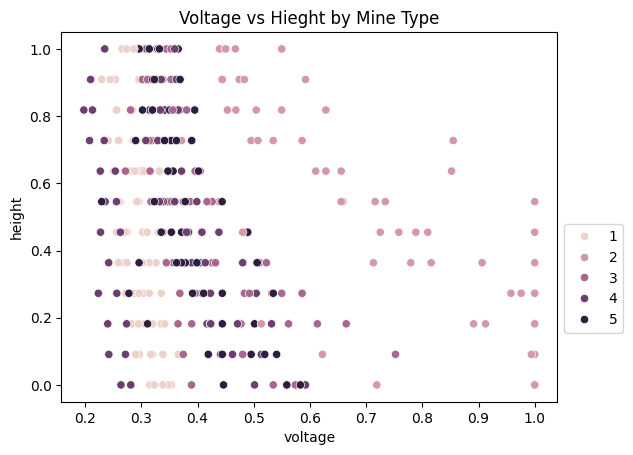

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=landmines,
    x='voltage',
    y='height',
    hue='mine_type'
)
plt.legend(bbox_to_anchor=(1, 0.5))
plt.title('Voltage vs Hieght by Mine Type')
plt.show()

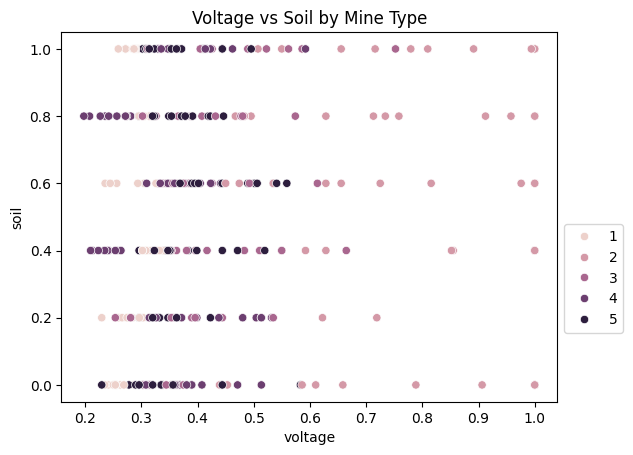

In [5]:
sns.scatterplot(
    data=landmines,
    x='voltage',
    y='soil',
    hue='mine_type'
)
plt.legend(bbox_to_anchor=(1, 0.5))
plt.title('Voltage vs Soil by Mine Type')
plt.show()

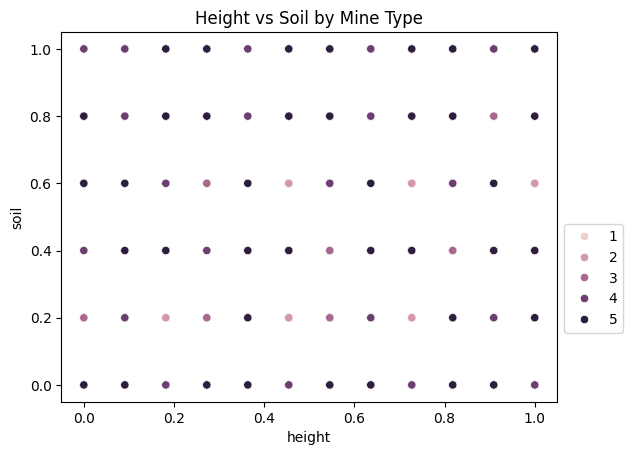

In [6]:
sns.scatterplot(
    data=landmines,
    x='height',
    y='soil',
    hue='mine_type'
)
plt.legend(bbox_to_anchor=(1, 0.5))
plt.title('Height vs Soil by Mine Type')
plt.show()

In [7]:
# 2
from sklearn.model_selection import train_test_split

def minmax(x):
    return (x-min(x))/(max(x)-min(x))

y = landmines['mine_type'] 
ctrl_list = ['voltage', 'height', 'soil'] 
x = landmines.loc[:, ctrl_list] 
u = x.apply(minmax) 

u_train, u_test, y_train, y_test = train_test_split(
    u, y, test_size=0.5, random_state=100)

In [8]:
# 3
from sklearn.neighbors import KNeighborsClassifier

k_grid = [1, 3, 5, 7, 9, 11]

best_k = None
best_acc = 0

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(u_train, y_train)
    acc = model.score(u_test, y_test)

    if acc > best_acc:
        best_acc = acc
        best_k = k

best_k, best_acc

(3, 0.40828402366863903)

k is selected by running through a loop that evaluates test-set classfiication accuracy for several odd values of k. The optimal k value is the one that produces the highest test-set accuracy. 

In [9]:
# 4
import numpy as np

k = 3 

model = KNeighborsClassifier(n_neighbors = k) 
model = model.fit(u_train,y_train) 

y_hat_train = model.predict(u_train)
y_hat_test  = model.predict(u_test)

pd.crosstab(y_test, y_hat_test)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat_test)

array([[28,  0,  5,  3,  2],
       [ 0, 24,  5,  2,  4],
       [ 8,  0, 10,  3, 12],
       [17,  2, 11,  4,  1],
       [12,  0, 11,  2,  3]])

In [10]:
test_acc = model.score(u_test, y_test)
print(test_acc)

0.40828402366863903


The k-NN classifier had an overall test accuracy of 41%. The prediction was more accurate for Classes 1 and 2 and less accurate for Classes 3, 4, and 5. In Classes 1 and 2, there are more distinctive patterns among the features, whereas in the others, the model misclassifies samples. 

**5.**
As we can see, the model is not fully accurate. Therefore, I would advise that this model be used as a tool to support decision-making rather than a final authority. It should not be used to automatically classify mines. Instead, it can be used to identify probable mine types and help determine whether cases need fine-tuning. Because there may be some misclassification, including false negatives, we should use this model with caution and human oversight.


### Q3.

In [11]:
# 1
cars = pd.read_csv('data/USA_cars_datasets.csv')
cars.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [12]:
cars = cars[['price', 'year', 'mileage']]
cars.isna().sum()

price      0
year       0
mileage    0
dtype: int64

In [13]:
cars.head(), cars.shape

(   price  year  mileage
 0   6300  2008   274117
 1   2899  2011   190552
 2   5350  2018    39590
 3  25000  2014    64146
 4  27700  2018     6654,
 (2499, 3))

In [14]:
# 2
cars["year_norm"] = (cars["year"] - cars["year"].min()) / (cars["year"].max() - cars["year"].min())
cars["mileage_norm"] = (cars["mileage"] - cars["mileage"].min()) / (cars["mileage"].max() - cars["mileage"].min())
cars[['year_norm', 'mileage_norm']].head()

,year_norm,mileage_norm
0,0.744681,0.269287
1,0.808511,0.187194
2,0.957447,0.038892
3,0.872340,0.063016
4,0.957447,0.006537


In [15]:
# 3
X = cars[["year_norm", "mileage_norm"]]
y = cars["price"]

X_train, X_eval, y_train, y_eval = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100
)

X_train.shape, X_eval.shape

((1999, 2), (500, 2))

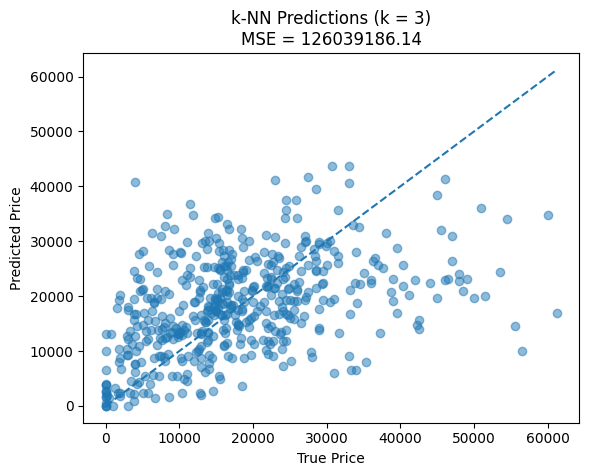

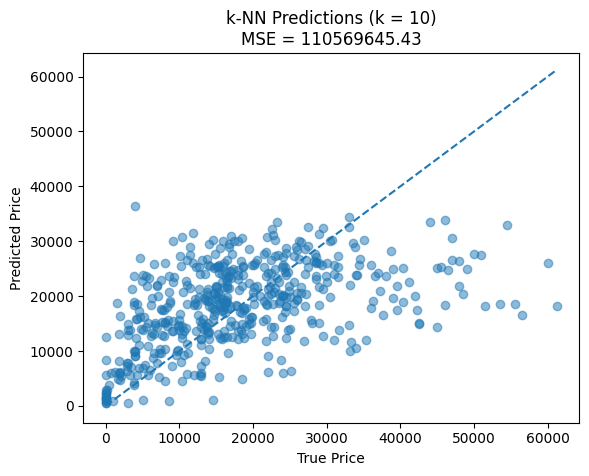

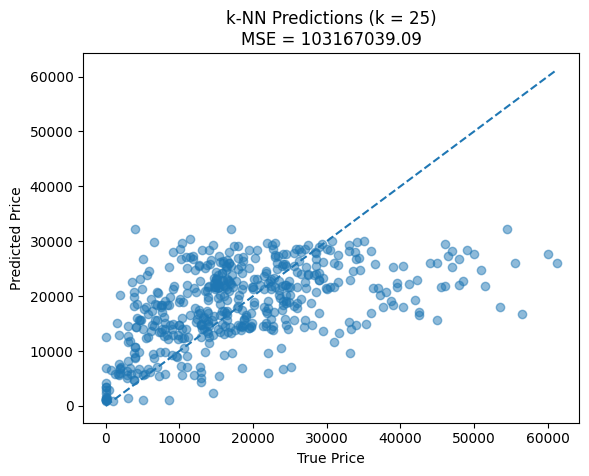

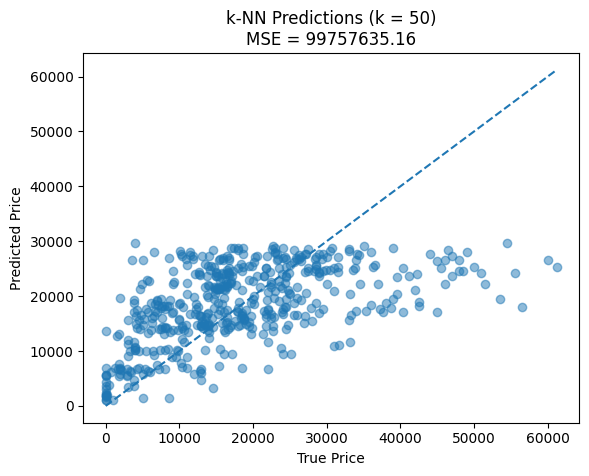

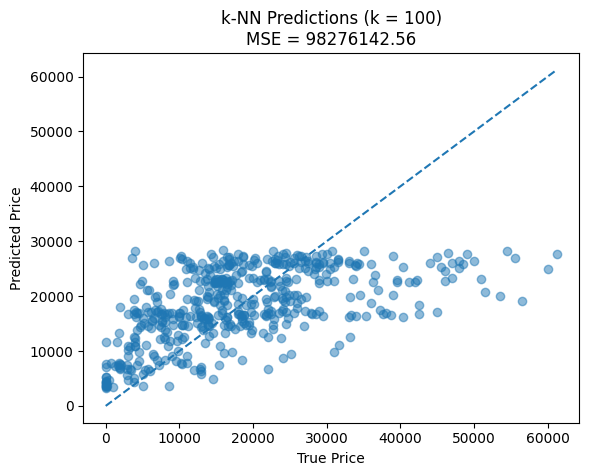

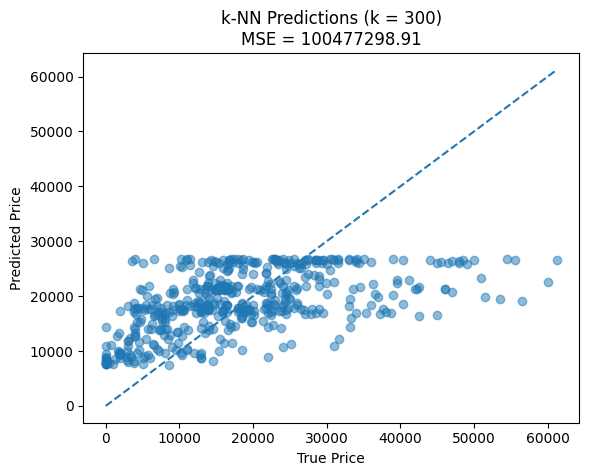

In [16]:
# 4
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3, 10, 25, 50, 100, 300]
results = {}

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_eval)

    mse = mean_squared_error(y_eval, y_pred)
    results[k] = mse

    plt.figure()
    plt.scatter(y_eval, y_pred, alpha=0.5)
    plt.plot([y_eval.min(), y_eval.max()],
                [y_eval.min(), y_eval.max()],
                linestyle="--")
    plt.xlabel("True Price")
    plt.ylabel("Predicted Price")
    plt.title(f"k-NN Predictions (k = {k})\nMSE = {mse:.2f}")
    plt.show()

In [17]:
for k, mse in results.items():
    print(f"k = {k:3d}, MSE = {mse:.2f}")

k =   3, MSE = 126039186.14
k =  10, MSE = 110569645.43
k =  25, MSE = 103167039.09
k =  50, MSE = 99757635.16
k = 100, MSE = 98276142.56
k = 300, MSE = 100477298.91


As k increases, the predictions become smoother. k=3 produced predictions that closely followed individual data points, whereas k=300 produced predictions that created a more narrow cluster of points around the overall average price. 

In [19]:
# 5
optimal_k = min(results, key=results.get)
print("Optimal k = ", optimal_k)

Optimal k =  100


As k increases, the model goes from overfitting to underfitting since variance decreases. For small values, the predictions chase noise and are very sensitive to individual data points, resulting in high variance. For large values, the predictions collapse into a narrow band near the overall mean, resulting in low variance. This failure to capture variation leads to increased error and underfitting.

### Q6.

In [20]:
# 1
airbnb = pd.read_csv("data/airbnb_hw.csv")

In [21]:
airbnb = airbnb.loc[:, ['Review Scores Rating', 'Price', 'Beds']]

if airbnb['Price'].dtype == 'O':
    airbnb['Price'] = airbnb['Price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

airbnb.head()

,Review Scores Rating,Price,Beds
0,NaN,145.0,1.0
1,NaN,37.0,1.0
2,NaN,28.0,1.0
3,NaN,199.0,3.0
4,96.0,549.0,3.0


In [22]:
# 2
airbnb_missing = airbnb.loc[airbnb['Review Scores Rating'].isnull(), :]
airbnb_missing.head()

,Review Scores Rating,Price,Beds
0,NaN,145.0,1.0
1,NaN,37.0,1.0
2,NaN,28.0,1.0
3,NaN,199.0,3.0
13,NaN,68.0,1.0


In [23]:
# 3
airbnb_complete = airbnb.dropna(axis = 0, how = 'any')
airbnb_complete.head()

,Review Scores Rating,Price,Beds
4,96.0,549.0,3.0
5,100.0,149.0,1.0
6,100.0,250.0,1.0
7,94.0,90.0,1.0
8,90.0,270.0,2.0


In [24]:
# 4
from sklearn.preprocessing import StandardScaler

X = airbnb_complete[['Price', 'Beds']]
y = airbnb_complete['Review Scores Rating']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=100)

k_values = range(1, 151)
sses = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    sse = np.sum((y_test - y_pred)**2)
    sses.append(sse)

best_k = k_values[np.argmin(sses)]
best_k

133

k is chosen by using a train/test split to avoid overfitting. For each possible value of k, the model is trained on the training data, allowing us to predict the review scores to compute SSE. The optimal k is the one that minimizes SSE on the test set, and does not severely overfit or underfit the data.

In [30]:
# 5
missing_mask = airbnb['Review Scores Rating'].isna()
X_missing = airbnb.loc[missing_mask, ['Price', 'Beds']]

valid_missing_mask = X_missing.dropna().index
X_missing_clean = X_missing.loc[valid_missing_mask]

X_missing_scaled = scaler.transform(X_missing_clean)
missing_ratings = airbnb.loc[valid_missing_mask, 'Review Scores Rating'] = knn.predict(X_missing_scaled)
missing_ratings

array([94.        , 86.28666667, 86.96666667, ..., 92.21333333,
       86.81333333, 92.21333333], shape=(8282,))

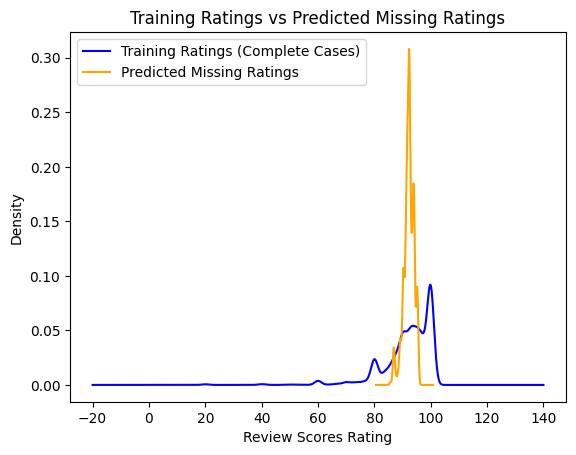

In [31]:
# 6
plt.figure()

airbnb_complete['Review Scores Rating'].plot.kde(label='Training Ratings (Complete Cases)', color='blue')

predicted_ratings = airbnb.loc[valid_missing_mask, 'Review Scores Rating']
predicted_ratings.plot.kde(label='Predicted Missing Ratings', color='orange')

plt.xlabel('Review Scores Rating')
plt.ylabel('Density')
plt.title('Training Ratings vs Predicted Missing Ratings')
plt.legend()
plt.show()

The distribution of predicted missing ratings is much more narrow and peaked than the distribution of training ratings. The prediction is composed of the means of neighbors, so this pulls the distirbution towards the mean.